Hola **Aron**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

## Importar Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest


## Crear Datasets

In [2]:
calls = pd.read_csv("/datasets/telecom_dataset_us.csv")
clients = pd.read_csv("/datasets/telecom_clients_us.csv")

## Explorar Datasets

In [3]:
print(calls.info())
print(clients.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    objec

In [4]:
calls.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [5]:
clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


# revisar valores nulos o duplicados

In [6]:
print(calls.isnull().sum())

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64


In [7]:
print(clients.isnull().sum())


user_id        0
tariff_plan    0
date_start     0
dtype: int64


In [8]:
print(calls.duplicated().sum())
print(clients.duplicated().sum())

4900
0


Observaciones de los duplicados y nulos: Vamos a eliminar los resultados duplicados y vamos a revisar si los resultados nulos no son llamadas perdidas o sea que almenos tengan un tiempo determinado de llamada. osease mayor a 0 la duracion de la llamada.

In [9]:
calls = calls.drop_duplicates()

In [10]:
calls.loc[calls['is_missed_call'] == 1, 'call_duration'] = calls['call_duration'].fillna(0)

In [11]:
calls = calls.dropna(subset=['operator_id', 'calls_count'])

In [12]:
print(calls.isnull().sum())

user_id                 0
date                    0
direction               0
internal               55
operator_id             0
is_missed_call          0
calls_count             0
call_duration           0
total_call_duration     0
dtype: int64


Los valores de la columna internal probablemente sea por ser llamadas internas no se les agrego si era de entrada o salida. habra que ver si los nulos estan asociados a algun tipo de llamada en especifica

In [13]:
print(calls[calls['internal'].isnull()]['direction'].value_counts())

in    55
Name: direction, dtype: int64


In [14]:
calls[calls['internal'].isnull()].head(10)

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
1924,166406,2019-09-02 00:00:00+03:00,in,NaN,879898.0,False,1,2,9
6210,166541,2019-09-26 00:00:00+03:00,in,NaN,908960.0,False,1,393,423
6216,166541,2019-09-26 00:00:00+03:00,in,NaN,908958.0,False,2,547,612
7528,166604,2019-11-01 00:00:00+03:00,in,NaN,893402.0,False,1,94,117
8650,166658,2019-09-24 00:00:00+03:00,in,NaN,890404.0,False,1,150,157
9080,166658,2019-10-15 00:00:00+03:00,in,NaN,890404.0,False,1,51,57
16180,166916,2019-10-01 00:00:00+03:00,in,NaN,906396.0,False,1,100,117
16304,166916,2019-10-07 00:00:00+03:00,in,NaN,906406.0,False,3,378,461
16569,166916,2019-10-23 00:00:00+03:00,in,NaN,906400.0,False,1,81,110
18647,166983,2019-09-02 00:00:00+03:00,in,NaN,901880.0,False,1,119,127


Observacion final : me parece que puede ser una mala practica entre operadores no llenar correctamente la casilla o la informacion en las llaamdas internas entre ellos 

# Revisar nombre de columnas

In [15]:
print(calls.columns.tolist())
print(clients.columns.tolist())

['user_id', 'date', 'direction', 'internal', 'operator_id', 'is_missed_call', 'calls_count', 'call_duration', 'total_call_duration']
['user_id', 'tariff_plan', 'date_start']


No veo detalles importantes en los nombres de las columnas

# Resumen estadístico de variables numéricas

In [16]:
print(calls[['calls_count', 'call_duration', 'total_call_duration']].describe())

        calls_count  call_duration  total_call_duration
count  41546.000000   41546.000000         41546.000000
mean      16.900424    1009.769172          1321.592813
std       59.749373    4064.106117          4785.978633
min        1.000000       0.000000             0.000000
25%        1.000000       0.000000            67.000000
50%        4.000000     106.000000           288.000000
75%       13.000000     770.000000          1104.000000
max     4817.000000  144395.000000        166155.000000


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien realizado el análisis inicial y el tratamiento de los dataset previo a su exploración, siempre hay que buscar tener la mejor calidad posible en tus datos
</div>

# Graficas

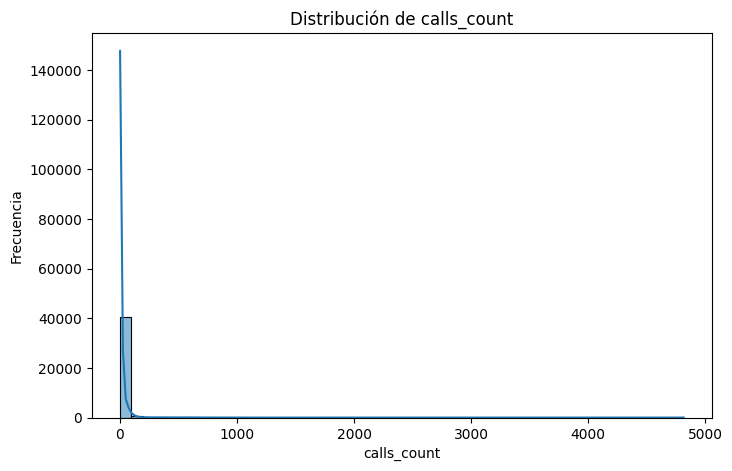

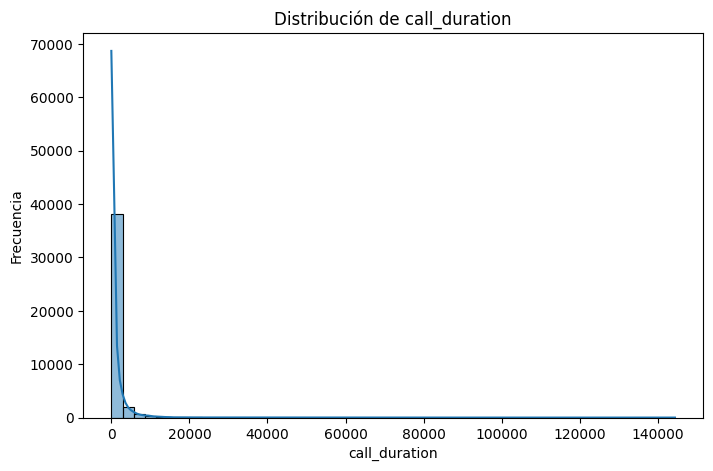

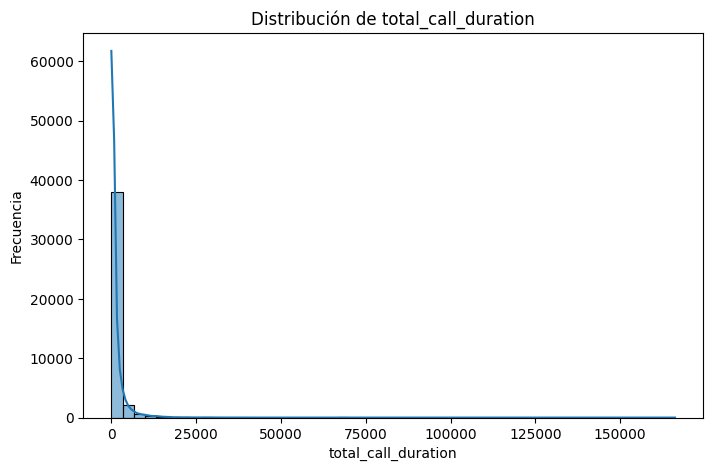

In [17]:
for col in ['calls_count', 'call_duration', 'total_call_duration']:
    plt.figure(figsize=(8,5))
    sns.histplot(calls[col], bins=50, kde=True)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

Observacion: LA PRIMERA OBSERVACIÓN QUE NOTAMOS AL INTENTAR TENER NUESTRAS PRIMERAS GRÁFICAS FUE QUE LA DURACIÓN DE LAS LLAMADAS SON MUY CORTAS O HAY MUY POCAS QUE DURAN UNA CANTIDAD DE MINUTOS ACEPTABLE PARA CONSIDERARLO UNA LLAMADA EXITOSA.

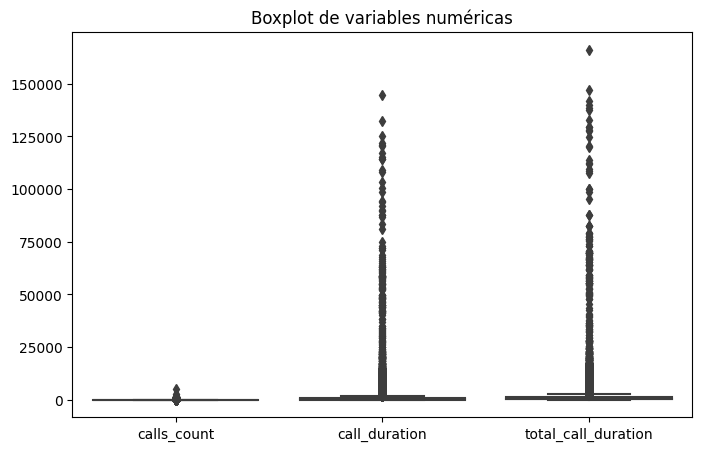

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data=calls[['calls_count', 'call_duration', 'total_call_duration']])
plt.title("Boxplot de variables numéricas")
plt.show()

Observacion: estas graficas demuestran actividades muy pobres o convalores muy bajos tanto en calls_count como en call_duration la mediana es muy baja y en la ultima caja hay una dispariedad gigante hay clientes que duran 1 minutos y otros que duran muchisimo algo esta mal en el servicio y como se maneja

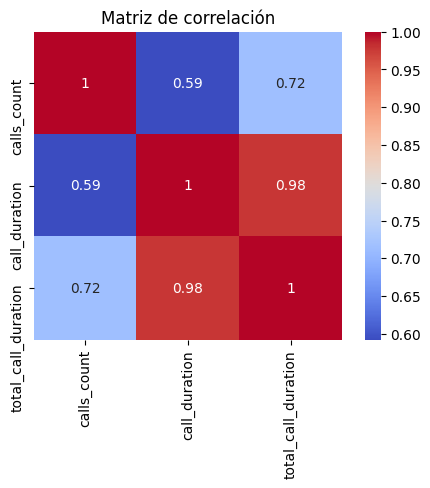

In [19]:
corr = calls[['calls_count', 'call_duration', 'total_call_duration']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", square=True)
plt.title("Matriz de correlación")
plt.show()

Observaciones: me da la impresion que hay muchas llamadas fallidas o que duran muy poco lo cual lleva a que la duracion sea corta.
en la grafica de caja o box da la sensacion de que el servicio esta muy disperso a que me refiero que no se ve estable la metrica. probablemente adecuado al tema de las malas practicas de las llamadas internas probablemente el servicio que se esta dando durante las llamadas estan siendo no de la mejor calidad o realizando de igual manera malas practicas.
en la ultima metrica da por hecho que se hacen muchas llamadas pero muy pocas duran los suficiente 

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Para que el análisis sea un poco más claro y fácil de seguir te recomiendo que siempre que muestres una gráfica dejes un breve comentario sobre la misma, así es más fácil entender la conclusión final de esta sección
</div>

# Segmentacion o KPIs de operadores y clientes

In [20]:
seg_operator = calls.groupby('operator_id').agg({
    'calls_count':'sum',
    'is_missed_call':'sum',
    'call_duration':'mean',
    'total_call_duration':'mean'
}).reset_index()

In [21]:
seg_operator['missed_ratio'] = seg_operator['is_missed_call'] / seg_operator['calls_count']

In [22]:

seg_operator.head()

,operator_id,calls_count,is_missed_call,call_duration,total_call_duration,missed_ratio
0,879896.0,930,47,545.829060,650.743590,0.050538
1,879898.0,7313,89,1133.881057,1591.577093,0.012170
2,880020.0,45,6,112.250000,126.250000,0.133333
3,880022.0,197,29,216.385714,270.357143,0.147208
4,880026.0,2232,87,842.450549,964.428571,0.038978


# Identificar operdores ineficientes

In [23]:
calls['waiting_time'] = (calls['total_call_duration'] - calls['call_duration']).clip(lower=0)

In [24]:
incoming = (calls.loc[calls['direction']=='in']
            .groupby('operator_id')['calls_count'].sum()
            .rename('incoming_calls'))

outgoing = (calls.loc[calls['direction']=='out']
            .groupby('operator_id')['calls_count'].sum()
            .rename('outgoing_calls'))

missed_in = (calls.loc[(calls['direction']=='in') & (calls['is_missed_call']==1)]
             .groupby('operator_id')['calls_count'].sum()
             .rename('missed_calls_in'))

wait_in_total = (calls.loc[calls['direction']=='in']
                 .groupby('operator_id')['waiting_time'].sum()
                 .rename('waiting_time_in_total'))

In [25]:
operator_stats = (pd.concat([incoming, outgoing, missed_in, wait_in_total], axis=1)
                    .fillna({'incoming_calls':0, 'outgoing_calls':0, 
                             'missed_calls_in':0, 'waiting_time_in_total':0})
                 )

In [26]:
operator_stats['missed_ratio_in'] = np.where(
    operator_stats['incoming_calls']>0,
    operator_stats['missed_calls_in'] / operator_stats['incoming_calls'],
    np.nan
)

In [27]:
operator_stats['avg_wait_in'] = np.where(
    operator_stats['incoming_calls']>0,
    operator_stats['waiting_time_in_total'] / operator_stats['incoming_calls'],
    np.nan
)

In [28]:
operator_stats['total_calls'] = operator_stats['incoming_calls'] + operator_stats['outgoing_calls']


Filtrando por volumen para evitar confusioneso marcar de ineficiente a alguien con poco tiempo o pocas llamadas

In [29]:
MIN_INCOMING = 50   
MIN_OUTGOING = 20   
operator_stats['enough_incoming'] = operator_stats['incoming_calls'] >= MIN_INCOMING
operator_stats['enough_outgoing'] = operator_stats['outgoing_calls'] >= MIN_OUTGOING

Observacion: ¿Por que elegir estos limites? 
aplicamos minimos de volumen de las llamadas para tener controlado o bien redactado la posible varianza y asegurarnos que las metricas tengan los menores errores posibles y asegurarnos que existan menos falsos positivos en nuestro quartiles o analisis de los datos.
de esta manera nos aseguramos de encontrar a los peores o mas ineficientes operadores.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Este tipo de decisiones deben quedar siempre muy claras, por lo que las razones para establecer estos límites para determinar si el operador es eficiente o no deben quedar correctamente explicadas.

Se debe argumentar el por qué de estos límites en base a los datos que tienes y el análisis realizado.
</div>

marcando los quartiles que serviran como metrica

In [30]:
MISS_RATIO_TH = 0.30
p75_wait = operator_stats.loc[operator_stats['enough_incoming'], 'avg_wait_in'].quantile(0.75)
p25_out  = operator_stats.loc[operator_stats['outgoing_calls']>0, 'outgoing_calls'].quantile(0.25)

In [31]:
operator_stats['inef_por_missed'] = operator_stats['enough_incoming'] & (operator_stats['missed_ratio_in'] > MISS_RATIO_TH)
operator_stats['inef_por_wait']   = operator_stats['enough_incoming'] & (operator_stats['avg_wait_in'] > p75_wait)
operator_stats['inef_por_out']    = (operator_stats['outgoing_calls']>0) & (operator_stats['outgoing_calls'] < p25_out)

In [32]:
operator_stats['ineficaz'] = operator_stats[['inef_por_missed','inef_por_wait','inef_por_out']].any(axis=1)

In [33]:
def razones(row):
    r=[]
    if row['inef_por_missed']: r.append(f"missed_ratio_in>{MISS_RATIO_TH:.0%}")
    if row['inef_por_wait']:   r.append("avg_wait_in>P75")
    if row['inef_por_out']:    r.append("outgoing_calls<P25")
    return ", ".join(r)

In [34]:
operator_stats['razones'] = operator_stats.apply(razones, axis=1)

ordenando los peores operadores primero

In [35]:
peores = operator_stats.sort_values(
    by=['missed_ratio_in','avg_wait_in','outgoing_calls'],
    ascending=[False, False, True]
)

In [36]:
ineficaces = peores.loc[peores['ineficaz']]
ineficaces_ids = ineficaces.index.tolist()


In [37]:
peores.head(8)

,incoming_calls,outgoing_calls,missed_calls_in,waiting_time_in_total,missed_ratio_in,avg_wait_in,total_calls,enough_incoming,enough_outgoing,inef_por_missed,inef_por_wait,inef_por_out,ineficaz,razones
operator_id,,,,,,,,,,,,,,
948756.0,1.0,170.0,1.0,8.0,1.000000,8.000000,171.0,False,True,False,False,False,False,
904344.0,4.0,5.0,3.0,55.0,0.750000,13.750000,9.0,False,False,False,False,True,True,outgoing_calls<P25
913886.0,2.0,0.0,1.0,27.0,0.500000,13.500000,2.0,False,False,False,False,False,False,
906392.0,18.0,53.0,7.0,249.0,0.388889,13.833333,71.0,False,True,False,False,False,False,
934098.0,6.0,0.0,2.0,159.0,0.333333,26.500000,6.0,False,False,False,False,False,False,
897872.0,3.0,49.0,1.0,65.0,0.333333,21.666667,52.0,False,True,False,False,False,False,
937432.0,3.0,19.0,1.0,36.0,0.333333,12.000000,22.0,False,False,False,False,False,False,
957922.0,3.0,16.0,1.0,26.0,0.333333,8.666667,19.0,False,False,False,False,False,False,


In [38]:
ineficaces.head(8)

,incoming_calls,outgoing_calls,missed_calls_in,waiting_time_in_total,missed_ratio_in,avg_wait_in,total_calls,enough_incoming,enough_outgoing,inef_por_missed,inef_por_wait,inef_por_out,ineficaz,razones
operator_id,,,,,,,,,,,,,,
904344.0,4.0,5.0,3.0,55.0,0.750000,13.750000,9.0,False,False,False,False,True,True,outgoing_calls<P25
937368.0,22.0,10.0,4.0,531.0,0.181818,24.136364,32.0,False,False,False,False,True,True,outgoing_calls<P25
944226.0,180.0,109.0,30.0,7679.0,0.166667,42.661111,289.0,True,True,False,True,False,True,avg_wait_in>P75
905862.0,102.0,1.0,15.0,1165.0,0.147059,11.421569,103.0,True,False,False,False,True,True,outgoing_calls<P25
918888.0,8.0,3.0,1.0,75.0,0.125000,9.375000,11.0,False,False,False,False,True,True,outgoing_calls<P25
926872.0,24.0,7.0,3.0,19.0,0.125000,0.791667,31.0,False,False,False,False,True,True,outgoing_calls<P25
888406.0,9.0,6.0,1.0,255.0,0.111111,28.333333,15.0,False,False,False,False,True,True,outgoing_calls<P25
928382.0,9.0,9.0,1.0,27.0,0.111111,3.000000,18.0,False,False,False,False,True,True,outgoing_calls<P25


el operador con id 904344.0 probablemente sea el operador mas ineficaz ya que aparece en la parte superior de ambas listas. 

# correlaciones entre por ejemplo número de llamadas recibidas y % de perdidas tiempo de espera y duración efectiva de la llamada

In [39]:
calls['waiting_time'] = (calls['total_call_duration'] - calls['call_duration']).clip(lower=0)

In [40]:
op_corr = calls.groupby('operator_id').agg(
    incoming_calls=('calls_count', lambda x: x[calls.loc[x.index,'direction']=='in'].sum()),
    missed_calls=('calls_count', lambda x: x[(calls.loc[x.index,'direction']=='in') & 
                                             (calls.loc[x.index,'is_missed_call']==1)].sum()),
    avg_waiting=('waiting_time','mean'),
    avg_duration=('call_duration','mean')
).reset_index()

In [41]:
op_corr['missed_ratio'] = op_corr['missed_calls'] / op_corr['incoming_calls']

Correlacion 1- llamadas recibidas vs % de llamadas perdidas

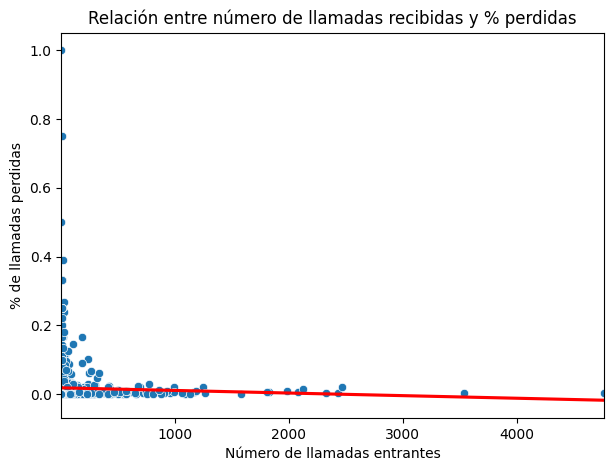

In [42]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=op_corr, x='incoming_calls', y='missed_ratio')
sns.regplot(data=op_corr, x='incoming_calls', y='missed_ratio',
            scatter=False, color='red', ci=None)
plt.title("Relación entre número de llamadas recibidas y % perdidas")
plt.xlabel("Número de llamadas entrantes")
plt.ylabel("% de llamadas perdidas")
plt.show()


Observcion de la grafica: 

Correlacion 2 Tiempo de espera vs Duracion efectiva

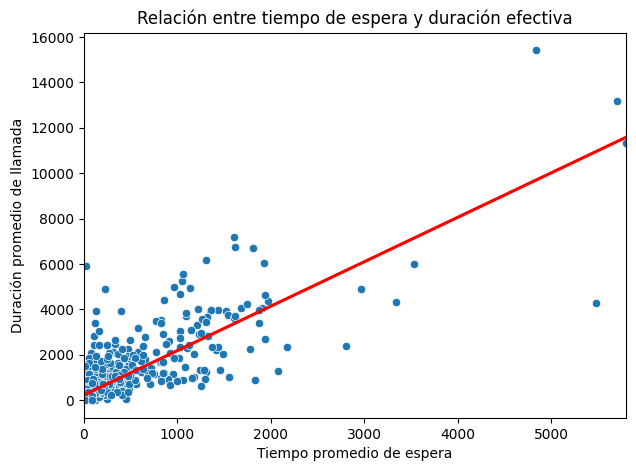

In [43]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=op_corr, x='avg_waiting', y='avg_duration')
sns.regplot(data=op_corr, x='avg_waiting', y='avg_duration',
            scatter=False, color='red', ci=None)
plt.title("Relación entre tiempo de espera y duración efectiva")
plt.xlabel("Tiempo promedio de espera")
plt.ylabel("Duración promedio de llamada")
plt.show()

Observaciones:
Podemos darnos cuenta que en la mayoria de graficas demuestran que el sistema de seguimiento o del mismo servicio requiere mucho trabajo, ¿Por que hago este comentario? por que las llamadas duran muy poco y muchas de esas llamadas que se hacen un gran % de ellos son perdidas o ni siqueira se empieza a ofrecer el servicio.

# Hipotesis Formal

Hipótesis 1: Llamadas perdidas

H0: La proporción de llamadas perdidas es igual en eficaces e ineficaces.

H1: Los ineficaces tienen mayor proporción de llamadas perdidas.
se usara el test: proportions_ztest

Hipótesis2: Tiempo de espera
H0: El tiempo de espera promedio es igual en eficaces e ineficaces.

H1: Los ineficaces tienen mayor tiempo de espera.
    
t-test unilateral (ttest_ind) si se cumple normalidad.
Mann-Whitney U si la distribución no es normal.

# validación de supuestos estadísticos

In [53]:
wait_eff = operator_stats.loc[~operator_stats['ineficaz'], 'avg_wait_in'].dropna()
wait_ineff = operator_stats.loc[operator_stats['ineficaz'], 'avg_wait_in'].dropna()


In [54]:
print("Shapiro-Wilk (eficaces):", stats.shapiro(wait_eff))
print("Shapiro-Wilk (ineficaces):", stats.shapiro(wait_ineff))

Shapiro-Wilk (eficaces): ShapiroResult(statistic=0.7861675024032593, pvalue=6.0352878222842476e-27)
Shapiro-Wilk (ineficaces): ShapiroResult(statistic=0.9706737995147705, pvalue=0.0011111273197457194)


In [55]:
mean_eff, std_eff = wait_eff.mean(), wait_eff.std()
mean_ineff, std_ineff = wait_ineff.mean(), wait_ineff.std()
print("Kolmogorov-Smirnov (eficaces):", stats.kstest(wait_eff, 'norm', args=(mean_eff, std_eff)))
print("Kolmogorov-Smirnov (ineficaces):", stats.kstest(wait_ineff, 'norm', args=(mean_ineff, std_ineff)))

Kolmogorov-Smirnov (eficaces): KstestResult(statistic=0.17594118608568587, pvalue=2.955707710298648e-16, statistic_location=18.03472222222222, statistic_sign=1)
Kolmogorov-Smirnov (ineficaces): KstestResult(statistic=0.061423115992264576, pvalue=0.5189632818285879, statistic_location=22.0, statistic_sign=1)


# igualdad de varianzas

In [56]:
stat, p_val = stats.levene(wait_eff, wait_ineff)
print("Levene p-value:", p_val)

if p_val < 0.05:
    print("Varianzas distintas: mejor usar t-test con 'equal_var=False' o Mann-Whitney.")
else:
    print("Varianzas homogéneas: t-test estándar aplicable.")

Levene p-value: 0.050385337253208366
Varianzas homogéneas: t-test estándar aplicable.


# Independencia

In [57]:
ops_per_client = calls.groupby('user_id')['operator_id'].nunique().sort_values(ascending=False)

print("Clientes con más operadores:")
print(ops_per_client.head(10))

Clientes con más operadores:
user_id
168187    50
167626    48
167497    30
168252    28
168361    27
168062    27
166680    21
166520    18
166658    17
166916    16
Name: operator_id, dtype: int64


Observacion interesante se supondria que cada cliente o user_id deberia tener un solo operador pero vemos que varios han tenido mas de 20 operadores eso que quiere decir que no hay practicamente nada de organizacion y seguimiento al servicio de cada cliente

# Hipotesis

# Hipotesis 1: Llamadas perdidas

In [46]:
missed_ineff = operator_stats.loc[operator_stats['ineficaz'], 'missed_calls_in'].sum()
total_in_ineff = operator_stats.loc[operator_stats['ineficaz'], 'incoming_calls'].sum()


In [47]:

missed_eff = operator_stats.loc[~operator_stats['ineficaz'], 'missed_calls_in'].sum()
total_in_eff = operator_stats.loc[~operator_stats['ineficaz'], 'incoming_calls'].sum()


Valores para el test, llamadas perdidas y llamadas entrantes

In [48]:
counts = np.array([missed_ineff, missed_eff])     
nobs   = np.array([total_in_ineff, total_in_eff]) 

In [49]:
stat, p_val = proportions_ztest(count=counts, nobs=nobs, alternative='larger')
print("p-value:", p_val)

if p_val < 0.05:
    print("Rechazamos H0: los ineficaces pierden significativamente más llamadas.")
else:
    print("No rechazamos H0: no hay evidencia de que pierdan más llamadas.")


p-value: 2.3888007982016677e-15
Rechazamos H0: los ineficaces pierden significativamente más llamadas.


observaciones : 
H0 (hipótesis nula):
La proporción de llamadas perdidas en operadores ineficaces es menor o igual a la de los eficaces.
H1 (hipótesis alternativa):
La proporción de llamadas perdidas en operadores ineficaces es mayor que la de los eficaces.

Si p-value < 0.05 → se rechaza H0 y se concluye que los operadores clasificados como ineficaces pierden significativamente más llamadas que los eficaces.

Si p-value ≥ 0.05 → no hay evidencia estadística suficiente para afirmar que los ineficaces pierden más; la diferencia observada puede ser debida al azar.

# Hipotesis 2: Tiempo de espera

In [51]:

t_stat, p_val_t = stats.ttest_ind(wait_ineff, wait_eff, alternative='greater')
print("T-test p-value:", p_val_t)


T-test p-value: 1.3105700927178243e-06


In [52]:

u_stat, p_val_u = stats.mannwhitneyu(wait_ineff, wait_eff, alternative='greater')
print("Mann-Whitney p-value:", p_val_u)

if p_val_u < 0.05:
    print("Rechazamos H0: ineficaces tienen mayor tiempo de espera.")
else:
    print("No rechazamos H0: no hay evidencia de mayor espera.")


Mann-Whitney p-value: 1.0636839613375364e-09
Rechazamos H0: ineficaces tienen mayor tiempo de espera.


Observaciones: 
H0 (nula): Los operadores ineficaces no tienen mayor tiempo de espera promedio que los eficaces.
H1 (alternativa): Los ineficaces tienen un mayor tiempo de espera promedio.

Si p < 0.05 (en cualquiera de los dos tests):
Se rechaza H0 → hay evidencia estadística de que los operadores ineficaces tienen mayor tiempo de espera en promedio (o en la distribución, según el test).

Si p ≥ 0.05:
No se rechaza H0 → no hay evidencia suficiente de que la espera sea mayor; la diferencia puede ser atribuible al azar.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Correcto, siempre se debe realizar pruebas estadísticas para determinar si las diferencias observadas son significativas y no se está sesgando el análisis.

Lo que si es que debes dejar claro cual es el H0 y el H1 que quieres comprobar aplicando estas pruebas estadísticas
</div>

Observaciones Finales

1- EL SISTEMA DEBE CAMBIAR
a qué me refiero con lo anterior. podemos darnos cuenta por el % de llamadas perdidas que la manera de contactar no está funcionando del todo a ¿que se puede deber esto? principalmente desconfianza si son todas llamadas telefónicas sin un pre-contacto la gente desconfía y no contesta el teléfono. si no tiene un contexto adecuado cuelgas el teléfono. nuestros operadores que ya están cometiendo errores. tienen menos probabilidades de concretar llamadas por que el sistema los tienen por decirlo de una manera con una mala presentación.

2- el sistema de control interno de las llamadas tiene que organizarse
Como nos dimos cuenta un cliente puede tener hasta 50 operadores para un solo cliente. una locura si quieres concretar una venta. no hay un seguimiento de qué operador atiende a que cliente. para concretar una venta o servicio. se requiere que haya una confianza con ese cliente y de esta manera no se podrá lograr los objetivos.


# link presentacion

In [ ]:
https://docs.google.com/presentation/d/1DuF9CZ1vPmJTy5xBperrIn5KqK9Wg-9hmW7XvBbD4MY/edit?usp=drive_link

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

No se puede acceder a la presentación ya que no se ha configurado correctamente, en la parte de compartir debes seleccionar la parte de "Cualquiera con el link" para que quien quiera revisar la presentación pueda ingresar sin problema.

Para esto puedes comprobar abriendo una ventana de tu navegador en modo incógnito y entrar al link que vas a compartir para ver si es accesible.
</div>

<div class="alert alert-block alert-success">
<b>Comentario general (2da Iteracion)</b> <a class=“tocSkip”></a>

**¡Te felicito por el trabajo realizado Aron!** Con este proyecto demuestras las habilidades adquiridas durante tu formación, se nota tu capacidad de contar historias con datos con la excelente presentación realizada que súper fácil de entender lo cual es una habilidad super importante cómo analista de datos, el saber comunicar de manera sencilla y eficiente los resultados de tus análisis.
    
Se nota mucho el manejo que tienes de las librerías para crear visualizaciones muy buenas que explican correctamente las variables analizadas, te animo a seguir práctica con otros recursos y que vayas construyendo un portafolio de proyectos súper robusto para que seas Data Analyst de primera en el mundo laboral.
   
Saludos!
</div>